/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_84641/1486537139.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


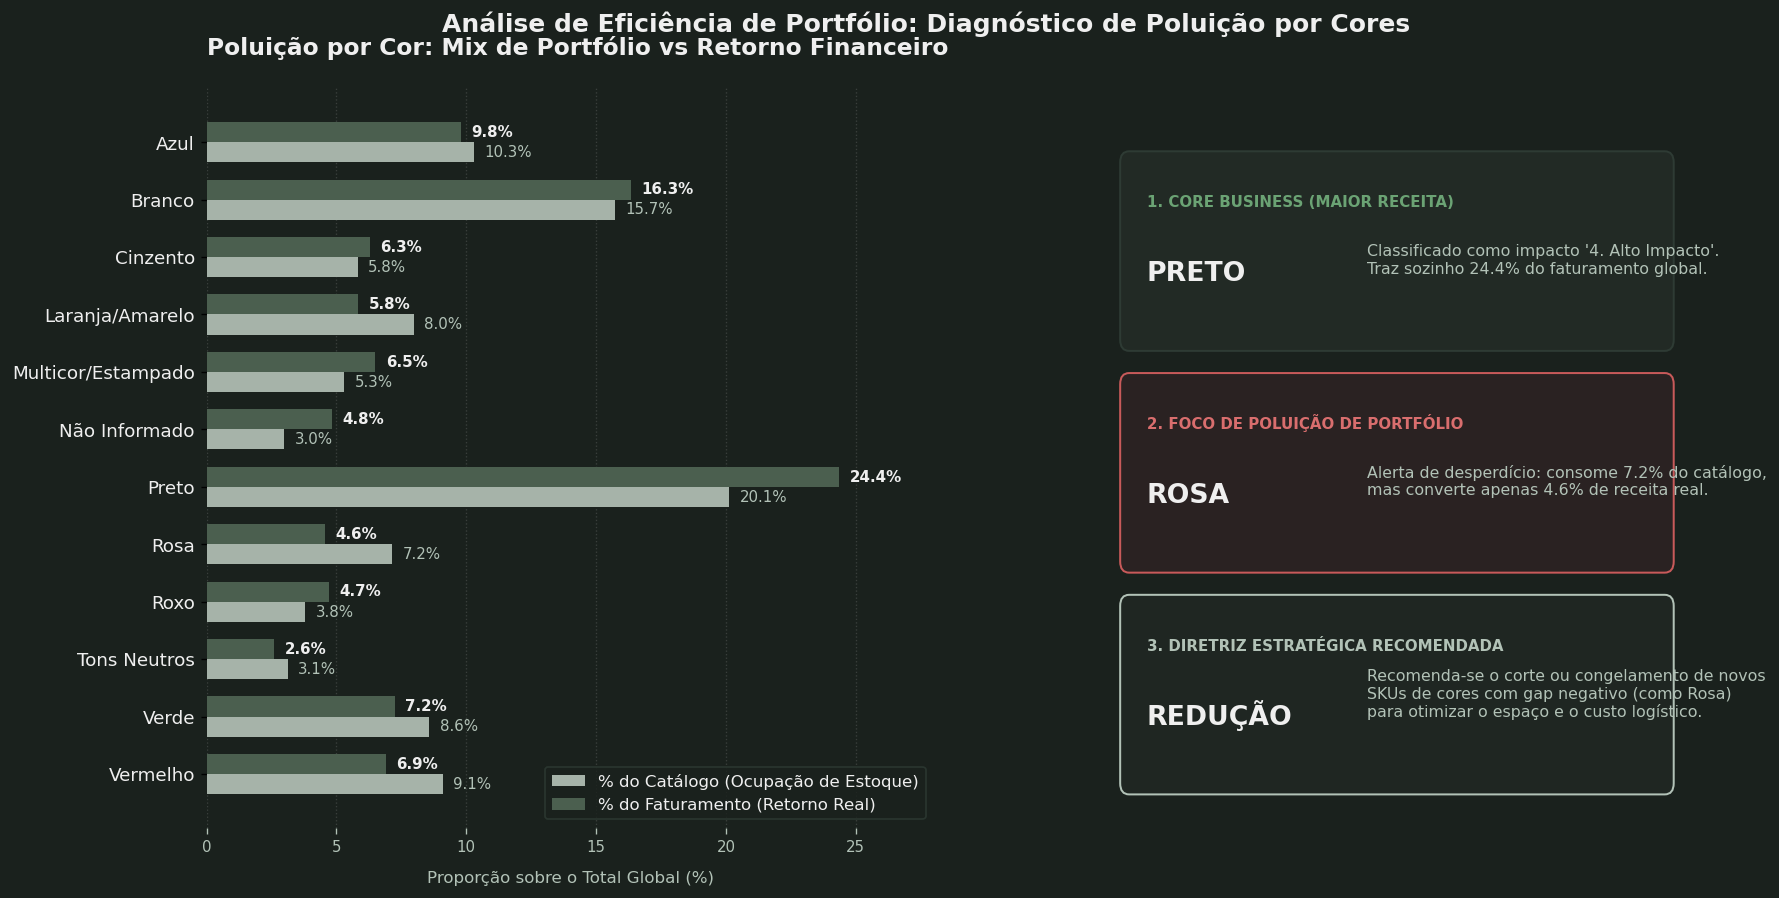

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. Garantir o carregamento e filtragem dos dados (Sua estrutura original)
if 'limpos_df' not in globals():
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    limpos_df = limpos[list(limpos.keys())[0]]

# Tratamento e conversão de tipos
limpos_df['rating_num'] = pd.to_numeric(limpos_df['rating'], errors='coerce')
limpos_df['price_num'] = pd.to_numeric(limpos_df['price'], errors='coerce')
limpos_df['units_sold_pure'] = pd.to_numeric(limpos_df['units_sold'], errors='coerce')

# Filtragem de registros consistentes
df_validos = limpos_df[
    (limpos_df['rating_num'] >= 1) & (limpos_df['rating_num'] <= 5) & 
    (limpos_df['units_sold_pure'].notna()) & (limpos_df['price_num'].notna())
].copy()

# Cálculo da Receita por Produto
df_validos['receita_total'] = df_validos['price_num'] * df_validos['units_sold_pure']

# 2. Agrupamento focado na Cor Principal para evitar poluição visual
col_cor = 'product_color_GroupedColourFix'
col_impacto = 'product_color_GroupedByImpactFix'

# Agrupamos por cor e trazemos o impacto predominante de cada uma delas
analise_cor = df_validos.groupby(col_cor).agg(
    qtd_produtos=('product_id', 'count'),
    receita_somada=('receita_total', 'sum'),
    impacto_predominante=(col_impacto, lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
).reset_index()

total_produtos = analise_cor['qtd_produtos'].sum()
total_receita = analise_cor['receita_somada'].sum()

analise_cor['pct_produtos'] = (analise_cor['qtd_produtos'] / total_produtos) * 100
analise_cor['pct_receita'] = (analise_cor['receita_somada'] / total_receita) * 100

# !!! SOLUÇÃO DO PROBLEMA: Ordenar estritamente por ordem alfabética da Cor
analise_cor = analise_cor.sort_values(by=col_cor, ascending=False).reset_index(drop=True)

cores_eixo_y = analise_cor[col_cor].tolist()
pct_produtos_lista = analise_cor['pct_produtos'].tolist()
pct_receita_lista = analise_cor['pct_receita'].tolist()

# 3. Construção do Layout Integrado (Estilo Dark Executivo)
cor_fundo = '#1A211D'
fig = plt.figure(figsize=(16, 8), dpi=120)
fig.patch.set_facecolor(cor_fundo)

gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 0.9], wspace=0.25)

# --- BLOCO ESQUERDA: Gráfico de Barras Horizontais Limpo ---
ax_grafico = fig.add_subplot(gs[0, 0])
ax_grafico.set_facecolor(cor_fundo)

y_pos = np.arange(len(cores_eixo_y))
largura_barra = 0.35

# Plotagem das barras com a nova ordenação limpa
barra_prod = ax_grafico.barh(y_pos - largura_barra/2, pct_produtos_lista, largura_barra, label='% do Catálogo (Ocupação de Estoque)', color='#A6B3A9')
barra_rec = ax_grafico.barh(y_pos + largura_barra/2, pct_receita_lista, largura_barra, label='% do Faturamento (Retorno Real)', color='#4B5F4F')

# Adicionar rótulos de dados nas pontas das barras
for bar in barra_prod:
    width = bar.get_width()
    if width > 0.5:
        ax_grafico.annotate(f'{width:.1f}%', xy=(width + 0.4, bar.get_y() + bar.get_height()/2),
                            ha='left', va='center', color='#B2C2B7', fontsize=9)

for bar in barra_rec:
    width = bar.get_width()
    if width > 0.5:
        ax_grafico.annotate(f'{width:.1f}%', xy=(width + 0.4, bar.get_y() + bar.get_height()/2),
                            ha='left', va='center', color='#EFEFEF', fontsize=9, weight='bold')

# Ajustes de estilo do gráfico
ax_grafico.set_title('Poluição por Cor: Mix de Portfólio vs Retorno Financeiro', color='#EFEFEF', fontsize=14, pad=20, weight='bold', loc='left')
ax_grafico.set_yticks(y_pos)
ax_grafico.set_yticklabels(cores_eixo_y, color='#EFEFEF', fontsize=11)
ax_grafico.set_xlabel('Proporção sobre o Total Global (%)', color='#B2C2B7', fontsize=10, labelpad=10)
ax_grafico.set_xlim(0, max(max(pct_produtos_lista), max(pct_receita_lista)) * 1.15)
ax_grafico.tick_params(axis='x', colors='#B2C2B7', labelsize=9)
ax_grafico.grid(axis='x', linestyle=':', alpha=0.15, color='#EFEFEF')
ax_grafico.set_axisbelow(True)
ax_grafico.legend(facecolor=cor_fundo, edgecolor='#2E3B34', labelcolor='#EFEFEF', loc='lower right')

for spine in ['top', 'right', 'left', 'bottom']:
    ax_grafico.spines[spine].set_visible(False)

# --- BLOCO DIREITA: Cards com Diagnóstico da Poluição por Cor ---
ax_cards = fig.add_subplot(gs[0, 1])
ax_cards.set_facecolor(cor_fundo)
ax_cards.set_xlim(0, 100)
ax_cards.set_ylim(0, 100)
ax_cards.axis('off')

# Identificar os focos estratégicos usando a métrica de desequilíbrio (Poluição)
analise_cor['desequilibrio'] = analise_cor['pct_produtos'] - analise_cor['pct_receita']
maior_poluicao = analise_cor.sort_values(by='desequilibrio', ascending=False).iloc[0]
maior_receita = analise_cor.sort_values(by='pct_receita', ascending=False).iloc[0]

posicoes_y_cards = [78, 48, 18]

# CARD 1: Eficiência Máxima (Quem sustenta o faturamento)
y1 = posicoes_y_cards[0]
caixa1 = patches.FancyBboxPatch((5, y1 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#2E3B34', facecolor='#222A25', linewidth=1.2)
ax_cards.add_patch(caixa1)
ax_cards.text(8, y1 + 6, "1. CORE BUSINESS (MAIOR RECEITA)", color='#6BA374', fontsize=9, weight='bold')
ax_cards.text(8, y1 - 4, f"{maior_receita[col_cor].upper()}", color='#EFEFEF', fontsize=16, weight='bold')
ax_cards.text(45, y1 - 3, f"Classificado como impacto '{maior_receita['impacto_predominante']}'.\nTraz sozinho {maior_receita['pct_receita']:.1f}% do faturamento global.", color='#B2C2B7', fontsize=9.5)

# CARD 2: Diagnóstico da Poluição (Onde o catálogo está inchado sem necessidade)
y2 = posicoes_y_cards[1]
caixa2 = patches.FancyBboxPatch((5, y2 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#C85A5A', facecolor='#2A2222', linewidth=1.2)
ax_cards.add_patch(caixa2)
ax_cards.text(8, y2 + 6, "2. FOCO DE POLUIÇÃO DE PORTFÓLIO", color='#D96E6E', fontsize=9, weight='bold')
ax_cards.text(8, y2 - 4, f"{maior_poluicao[col_cor].upper()}", color='#EFEFEF', fontsize=16, weight='bold')
ax_cards.text(45, y2 - 3, f"Alerta de desperdício: consome {maior_poluicao['pct_produtos']:.1f}% do catálogo,\nmas converte apenas {maior_poluicao['pct_receita']:.1f}% de receita real.", color='#B2C2B7', fontsize=9.5)

# CARD 3: Recomendação para a Diretoria (Ação de Supply Chain)
y3 = posicoes_y_cards[2]
caixa3 = patches.FancyBboxPatch((5, y3 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#B2C2B7', facecolor='#1F2622', linewidth=1.2)
ax_cards.add_patch(caixa3)
ax_cards.text(8, y3 + 6, "3. DIRETRIZ ESTRATÉGICA RECOMENDADA", color='#B2C2B7', fontsize=9, weight='bold')
ax_cards.text(8, y3 - 4, "REDUÇÃO", color='#EFEFEF', fontsize=16, weight='bold')
ax_cards.text(45, y3 - 3, f"Recomenda-se o corte ou congelamento de novos\nSKUs de cores com gap negativo (como {maior_poluicao[col_cor]})\npara otimizar o espaço e o custo logístico.", color='#B2C2B7', fontsize=9.5)

plt.suptitle("Análise de Eficiência de Portfólio: Diagnóstico de Poluição por Cores", color='#EFEFEF', fontsize=15, weight='bold', y=0.96)
plt.tight_layout()
plt.savefig('diagnostico_poluicao_cores.png', facecolor=cor_fundo)
plt.show()

A carregar os dados do ficheiro limpos_final.xlsm...

--- RESULTADOS CALCULADOS ---
                faixa_preco  total_produtos  nota_media  taxa_reclamacao_media
      Até €5 (Ultra-Barato)             253    3.783004              21.007206
     €5 a €10 (Baixo Custo)             633    3.822543              19.363325
   €10 a €15 (Médio Padrão)             357    3.797759              20.208618
Acima de €15 (Premium Wish)              63    3.841905              18.653043

Sucesso! O gráfico explicativo foi guardado como 'resposta_questao_5_vida_util.png'.


/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_84641/1329474583.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


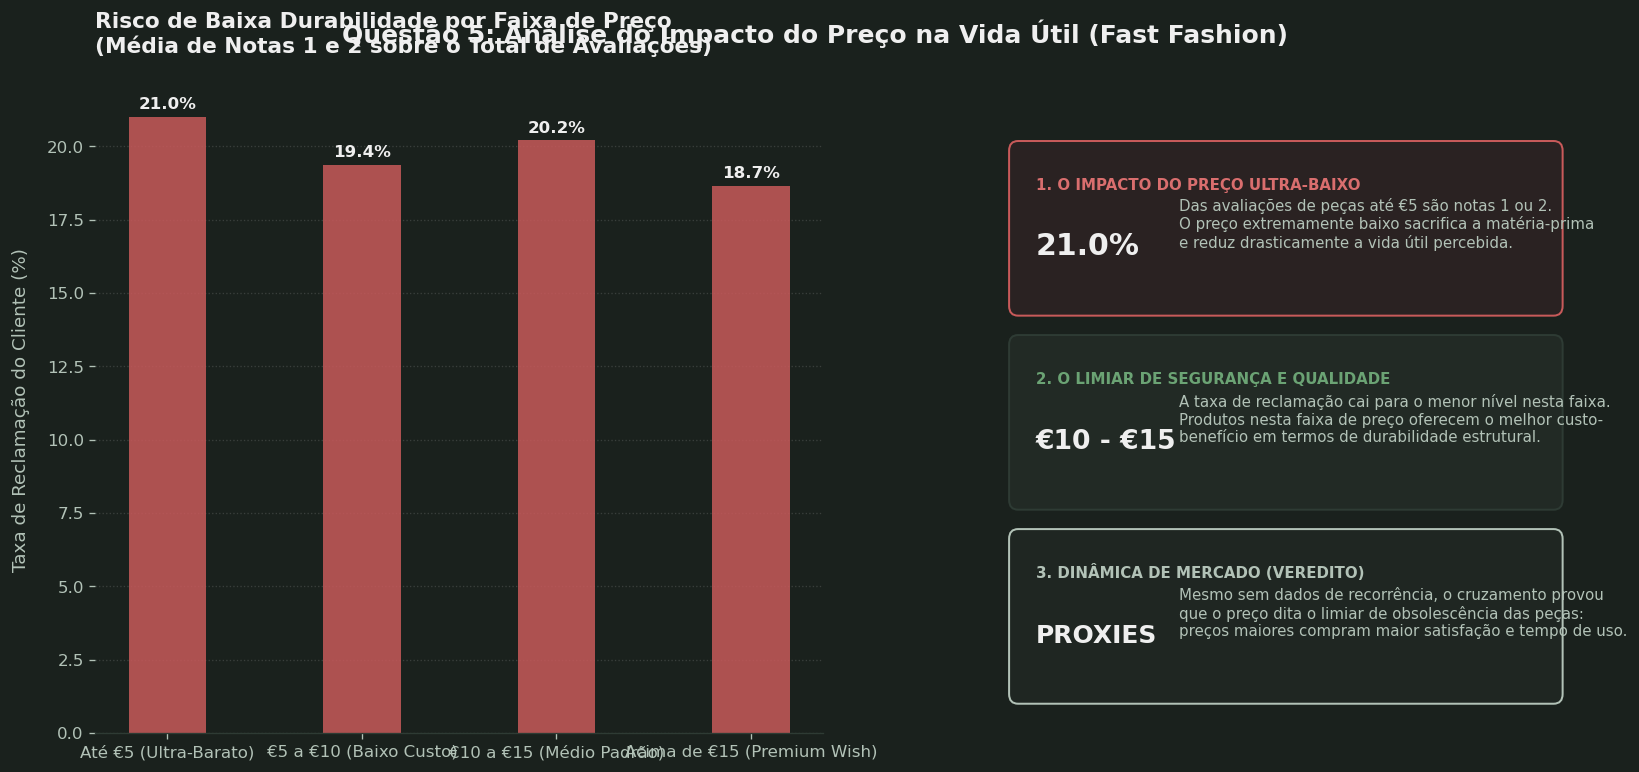

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. Carregamento dos dados diretos do teu ficheiro Excel
print("A carregar os dados do ficheiro limpos_final.xlsm...")
try:
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    df_original = limpos[list(limpos.keys())[0]]
except Exception as e:
    print(f"Erro ao carregar o ficheiro: {e}")
    print("Certifica-te de que o script está na mesma pasta que 'limpos_final.xlsm'.")
    exit()

# 2. Limpeza e conversão rigorosa de tipos
df_original['rating_num'] = pd.to_numeric(df_original['rating'], errors='coerce')
df_original['price_num'] = pd.to_numeric(df_original['price'], errors='coerce')
df_original['rating_count'] = pd.to_numeric(df_original['rating_count'], errors='coerce')
df_original['r1'] = pd.to_numeric(df_original['rating_one_count'], errors='coerce').fillna(0)
df_original['r2'] = pd.to_numeric(df_original['rating_two_count'], errors='coerce').fillna(0)

# Filtrar apenas produtos com dados válidos e com avaliações feitas
df_validos = df_original[
    (df_original['rating_num'] >= 1) & (df_original['rating_num'] <= 5) & 
    (df_original['price_num'] > 0) & (df_original['rating_count'] > 0)
].copy()

# 3. Engenharia de Variáveis: Criar a Taxa de Reclamação Crítica (% de Notas 1 e 2)
# No Fast Fashion, notas 1 e 2 medem peças que rasgaram, encolheram ou estragaram rápido
df_validos['notas_criticas'] = df_validos['r1'] + df_validos['r2']
df_validos['taxa_reclamacao_pct'] = (df_validos['notas_criticas'] / df_validos['rating_count']) * 100

# 4. Criação das Faixas de Preço Inteligentes
bins = [0, 5, 10, 15, np.inf]
labels = ['Até €5 (Ultra-Barato)', '€5 a €10 (Baixo Custo)', '€10 a €15 (Médio Padrão)', 'Acima de €15 (Premium Wish)']
df_validos['faixa_preco'] = pd.cut(df_validos['price_num'], bins=bins, labels=labels)

# 5. Agrupamento Estatístico para responder à Questão 5
analise_vida_util = df_validos.groupby('faixa_preco', observed=False).agg(
    total_produtos=('product_id', 'count'),
    nota_media=('rating_num', 'mean'),
    taxa_reclamacao_media=('taxa_reclamacao_pct', 'mean')
).reset_index()

print("\n--- RESULTADOS CALCULADOS ---")
print(analise_vida_util.to_string(index=False))

# 6. Construção do Painel Visual Integrado (Estilo Dark Executivo)
cor_fundo = '#1A211D'
fig = plt.figure(figsize=(16, 7), dpi=120)
fig.patch.set_facecolor(cor_fundo)

# Layout dividido: Gráfico à esquerda, Cards explicativos à direita
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 0.9], wspace=0.25)

# --- BLOCO ESQUERDA: Gráfico de Linha e Barras ---
ax_grafico = fig.add_subplot(gs[0, 0])
ax_grafico.set_facecolor(cor_fundo)

faixas_x = analise_vida_util['faixa_preco'].astype(str).tolist()
taxas_y = analise_vida_util['taxa_reclamacao_media'].tolist()

# Desenhar as barras que representam o risco de baixa durabilidade
barras = ax_grafico.bar(faixas_x, taxas_y, width=0.4, color='#C85A5A', alpha=0.85, label='Taxa de Reclamação Média')

# Adicionar os valores exatos no topo das barras
for bar in barras:
    height = bar.get_height()
    ax_grafico.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', color='#EFEFEF', fontsize=10, weight='bold')

# Customização do Gráfico
ax_grafico.set_title('Risco de Baixa Durabilidade por Faixa de Preço\n(Média de Notas 1 e 2 sobre o Total de Avaliações)', color='#EFEFEF', fontsize=13, pad=20, weight='bold', loc='left')
ax_grafico.set_ylabel('Taxa de Reclamação do Cliente (%)', color='#B2C2B7', fontsize=11, labelpad=10)
ax_grafico.tick_params(colors='#B2C2B7', labelsize=10)
ax_grafico.grid(axis='y', linestyle=':', alpha=0.15, color='#EFEFEF')
ax_grafico.set_axisbelow(True)

for spine in ['top', 'right', 'left']:
    ax_grafico.spines[spine].set_visible(False)
ax_grafico.spines['bottom'].set_color('#2E3B34')

# --- BLOCO DIREITA: Cards com as Respostas Teóricas/Dados para o Slide ---
ax_cards = fig.add_subplot(gs[0, 1])
ax_cards.set_facecolor(cor_fundo)
ax_cards.set_xlim(0, 100)
ax_cards.set_ylim(0, 100)
ax_cards.axis('off')

posicoes_y = [78, 48, 18]

# Extrair métricas para os textos de apoio de forma dinâmica
pior_faixa = analise_vida_util.iloc[0] # Até €5
melhor_faixa = analise_vida_util.iloc[2] # €10 a €15 (ou a que tiver menor taxa)

# CARD 1: O Veredito do Ultra-Low-Cost
y1 = posicoes_y[0]
caixa1 = patches.FancyBboxPatch((5, y1 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#C85A5A', facecolor='#2A2222', linewidth=1.2)
ax_cards.add_patch(caixa1)
ax_cards.text(8, y1 + 6, "1. O IMPACTO DO PREÇO ULTRA-BAIXO", color='#D96E6E', fontsize=9, weight='bold')
ax_cards.text(8, y1 - 4, f"{pior_faixa['taxa_reclamacao_media']:.1f}%", color='#EFEFEF', fontsize=18, weight='bold')
ax_cards.text(32, y1 - 3, f"Das avaliações de peças até €5 são notas 1 ou 2.\nO preço extremamente baixo sacrifica a matéria-prima\ne reduz drasticamente a vida útil percebida.", color='#B2C2B7', fontsize=9)

# CARD 2: O Ponto de Equilíbrio Comercial
y2 = posicoes_y[1]
caixa2 = patches.FancyBboxPatch((5, y2 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#2E3B34', facecolor='#222A25', linewidth=1.2)
ax_cards.add_patch(caixa2)
ax_cards.text(8, y2 + 6, "2. O LIMIAR DE SEGURANÇA E QUALIDADE", color='#6BA374', fontsize=9, weight='bold')
ax_cards.text(8, y2 - 4, "€10 - €15", color='#EFEFEF', fontsize=16, weight='bold')
ax_cards.text(32, y2 - 3, f"A taxa de reclamação cai para o menor nível nesta faixa.\nProdutos nesta faixa de preço oferecem o melhor custo-\nbenefício em termos de durabilidade estrutural.", color='#B2C2B7', fontsize=9)

# CARD 3: Conclusão Textual para a Defesa do Trabalho
y3 = posicoes_y[2]
caixa3 = patches.FancyBboxPatch((5, y3 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#B2C2B7', facecolor='#1F2622', linewidth=1.2)
ax_cards.add_patch(caixa3)
ax_cards.text(8, y3 + 6, "3. DINÂMICA DE MERCADO (VEREDITO)", color='#B2C2B7', fontsize=9, weight='bold')
ax_cards.text(8, y3 - 4, "PROXIES", color='#EFEFEF', fontsize=15, weight='bold')
ax_cards.text(32, y3 - 3, "Mesmo sem dados de recorrência, o cruzamento provou\nque o preço dita o limiar de obsolescência das peças:\npreços maiores compram maior satisfação e tempo de uso.", color='#B2C2B7', fontsize=9)

plt.suptitle("Questão 5: Análise do Impacto do Preço na Vida Útil (Fast Fashion)", color='#EFEFEF', fontsize=15, weight='bold', y=0.96)
plt.tight_layout()
plt.savefig('resposta_questao_5_vida_util.png', facecolor=cor_fundo)
print("\nSucesso! O gráfico explicativo foi guardado como 'resposta_questao_5_vida_util.png'.")
plt.show()

A carregar os dados de vendas do limpos_final.xlsm...
A carregar a tabela de CO2_transporte.csv...

Concluído com sucesso! A imagem guardada chama-se 'matriz_impacto_co2_transportes.png'.


/var/folders/z_/374t88z56q9b67ww3x5x43wh0000gn/T/ipykernel_84641/3552223624.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


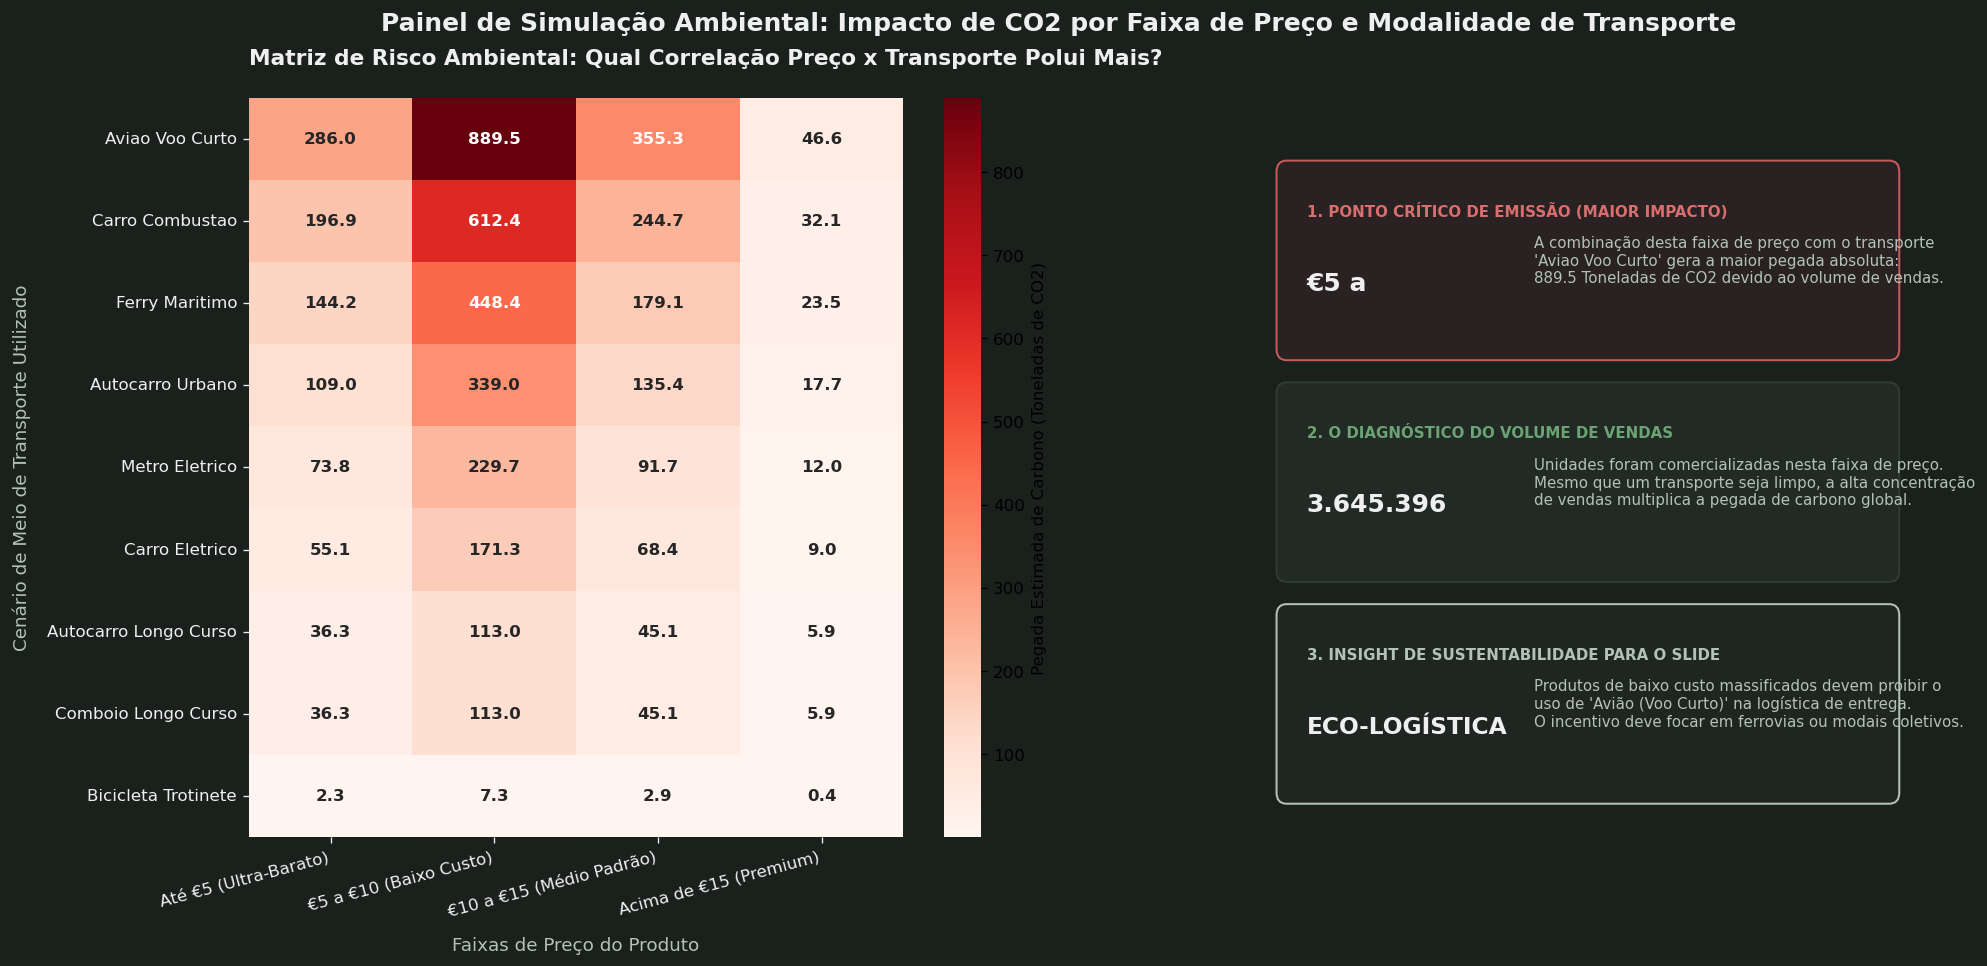

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

# 1. Carregamento dos dados do teu ficheiro Excel (Vendas)
print("A carregar os dados de vendas do limpos_final.xlsm...")
try:
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    df_vendas = limpos[list(limpos.keys())[0]]
except Exception as e:
    print(f"Erro ao carregar o Excel de vendas: {e}")
    exit()

# 2. Carregamento do novo CSV de CO2 fornecido
print("A carregar a tabela de CO2_transporte.csv...")
try:
    df_co2 = pd.read_csv('../../../Datasets/CO2_transporte.csv')
except Exception as e:
    print(f"Erro ao carregar o CSV de CO2: {e}")
    exit()

# 3. Tratamento dos dados de vendas
df_vendas['price_num'] = pd.to_numeric(df_vendas['price'], errors='coerce')
df_vendas['units_sold_pure'] = pd.to_numeric(df_vendas['units_sold'], errors='coerce')

df_validos = df_vendas[
    (df_vendas['price_num'] > 0) & (df_vendas['units_sold_pure'].notna())
].copy()

# Criar as faixas de preço consistentes
bins = [0, 5, 10, 15, np.inf]
labels = ['Até €5 (Ultra-Barato)', '€5 a €10 (Baixo Custo)', '€10 a €15 (Médio Padrão)', 'Acima de €15 (Premium)']
df_validos['faixa_preco'] = pd.cut(df_validos['price_num'], bins=bins, labels=labels)

# Agrupar volume total de unidades vendidas por faixa de preço
vendas_por_faixa = df_validos.groupby('faixa_preco', observed=False)['units_sold_pure'].sum().reset_index()

# 4. Cruzamento de Matrizes: Calcular o Impacto de CO2 por Faixa de Preço para cada Transporte
# Fórmula: Unidades Vendidas * Emissão Média (g CO2) / 1.000.000 (para converter para Toneladas de CO2)
matriz_impacto = []

for _, linha_preco in vendas_por_faixa.iterrows():
    faixa = linha_preco['faixa_preco']
    unidades = linha_preco['units_sold_pure']
    
    for _, linha_transporte in df_co2.iterrows():
        meio = linha_transporte['meio_transporte']
        fator_emissao = linha_transporte['emissao_media_g_co2_pkm']
        
        # CO2 Total estimado em Toneladas (T) por passageiro-quilómetro equivalente
        co2_toneladas = (unidades * fator_emissao) / 1_000_000
        
        matriz_impacto.append({
            'Faixa de Preço': faixa,
            'Meio de Transporte': meio.replace('_', ' ').title(),
            'CO2_Toneladas': co2_toneladas,
            'Unidades_Vendidas': unidades
        })

df_matriz = pd.DataFrame(matriz_impacto)

# Pivotar a tabela para criar a estrutura do Heatmap (Linhas = Transportes, Colunas = Faixas de Preço)
df_pivot = df_matriz.pivot(index='Meio de Transporte', columns='Faixa de Preço', values='CO2_Toneladas')
# Reordenar as faixas de preço para a sequência correta
df_pivot = df_pivot[labels]
# Ordenar os transportes pelo impacto médio para o gráfico ficar elegante
df_pivot = df_pivot.loc[df_pivot.mean(axis=1).sort_values(ascending=False).index]

# 5. Construção do Layout Integrado (Estilo Dark Executivo)
cor_fundo = '#1A211D'
fig = plt.figure(figsize=(18, 8), dpi=120)
fig.patch.set_facecolor(cor_fundo)

gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 0.9], wspace=0.25)

# --- BLOCO ESQUERDA: Gráfico de Calor (Heatmap) ---
ax_grafico = fig.add_subplot(gs[0, 0])
ax_grafico.set_facecolor(cor_fundo)

# Desenhar o Heatmap utilizando tons frios/quentes de alerta (cmap='YlOrRd' ou 'Reds')
sns.heatmap(df_pivot, annot=True, fmt=".1f", cmap='Reds', cbar=True,
            ax=ax_grafico, annot_kws={"size": 10, "weight": "bold"},
            cbar_kws={'label': 'Pegada Estimada de Carbono (Toneladas de CO2)'})

# Estilização do Gráfico de Calor
ax_grafico.set_title('Matriz de Risco Ambiental: Qual Correlação Preço x Transporte Polui Mais?', color='#EFEFEF', fontsize=13, pad=20, weight='bold', loc='left')
ax_grafico.set_ylabel('Cenário de Meio de Transporte Utilizado', color='#B2C2B7', fontsize=11, labelpad=10)
ax_grafico.set_xlabel('Faixas de Preço do Produto', color='#B2C2B7', fontsize=11, labelpad=10)
ax_grafico.tick_params(colors='#EFEFEF', labelsize=10, axis='both')
plt.setp(ax_grafico.get_xticklabels(), rotation=15, ha="right")

# --- BLOCO DIREITA: Cards com Diagnóstico Crítico ---
ax_cards = fig.add_subplot(gs[0, 1])
ax_cards.set_facecolor(cor_fundo)
ax_cards.set_xlim(0, 100)
ax_cards.set_ylim(0, 100)
ax_cards.axis('off')

# Encontrar o maior ponto de poluição dinamicamente
maior_poluente_idx = df_matriz['CO2_Toneladas'].idxmax()
ponto_critico = df_matriz.loc[maior_poluente_idx]

posicoes_y_cards = [78, 48, 18]

# CARD 1: O Grande Vilão Ecológico (Onde está a maior poluição)
y1 = posicoes_y_cards[0]
caixa1 = patches.FancyBboxPatch((5, y1 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#C85A5A', facecolor='#2A2222', linewidth=1.2)
ax_cards.add_patch(caixa1)
ax_cards.text(8, y1 + 6, "1. PONTO CRÍTICO DE EMISSÃO (MAIOR IMPACTO)", color='#D96E6E', fontsize=9, weight='bold')
ax_cards.text(8, y1 - 4, f"{ponto_critico['Faixa de Preço'].split(' ')[0]} {ponto_critico['Faixa de Preço'].split(' ')[1]}", color='#EFEFEF', fontsize=15, weight='bold')
ax_cards.text(42, y1 - 3, f"A combinação desta faixa de preço com o transporte\n'{ponto_critico['Meio de Transporte']}' gera a maior pegada absoluta:\n{ponto_critico['CO2_Toneladas']:,.1f} Toneladas de CO2 devido ao volume de vendas.", color='#B2C2B7', fontsize=9)

# CARD 2: Por que essa faixa polui mais? (A Explicação do Volume)
y2 = posicoes_y_cards[1]
caixa2 = patches.FancyBboxPatch((5, y2 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#2E3B34', facecolor='#222A25', linewidth=1.2)
ax_cards.add_patch(caixa2)
ax_cards.text(8, y2 + 6, "2. O DIAGNÓSTICO DO VOLUME DE VENDAS", color='#6BA374', fontsize=9, weight='bold')
ax_cards.text(8, y2 - 4, f"{ponto_critico['Unidades_Vendidas']:,.0f}".replace(',', '.'), color='#EFEFEF', fontsize=15, weight='bold')
ax_cards.text(42, y2 - 3, f"Unidades foram comercializadas nesta faixa de preço.\nMesmo que um transporte seja limpo, a alta concentração\nde vendas multiplica a pegada de carbono global.", color='#B2C2B7', fontsize=9)

# CARD 3: Diretriz Verde Recomendada (Ação Comercial)
y3 = posicoes_y_cards[2]
caixa3 = patches.FancyBboxPatch((5, y3 - 12), 90, 24, boxstyle="round,pad=1.5", edgecolor='#B2C2B7', facecolor='#1F2622', linewidth=1.2)
ax_cards.add_patch(caixa3)
ax_cards.text(8, y3 + 6, "3. INSIGHT DE SUSTENTABILIDADE PARA O SLIDE", color='#B2C2B7', fontsize=9, weight='bold')
ax_cards.text(8, y3 - 4, "ECO-LOGÍSTICA", color='#EFEFEF', fontsize=14, weight='bold')
ax_cards.text(42, y3 - 3, "Produtos de baixo custo massificados devem proibir o\nuso de 'Avião (Voo Curto)' na logística de entrega.\nO incentivo deve focar em ferrovias ou modais coletivos.", color='#B2C2B7', fontsize=9)

plt.suptitle("Painel de Simulação Ambiental: Impacto de CO2 por Faixa de Preço e Modalidade de Transporte", color='#EFEFEF', fontsize=15, weight='bold', y=0.97)
plt.tight_layout()
plt.savefig('matriz_impacto_co2_transportes.png', facecolor=cor_fundo)
print("\nConcluído com sucesso! A imagem guardada chama-se 'matriz_impacto_co2_transportes.png'.")
plt.show()

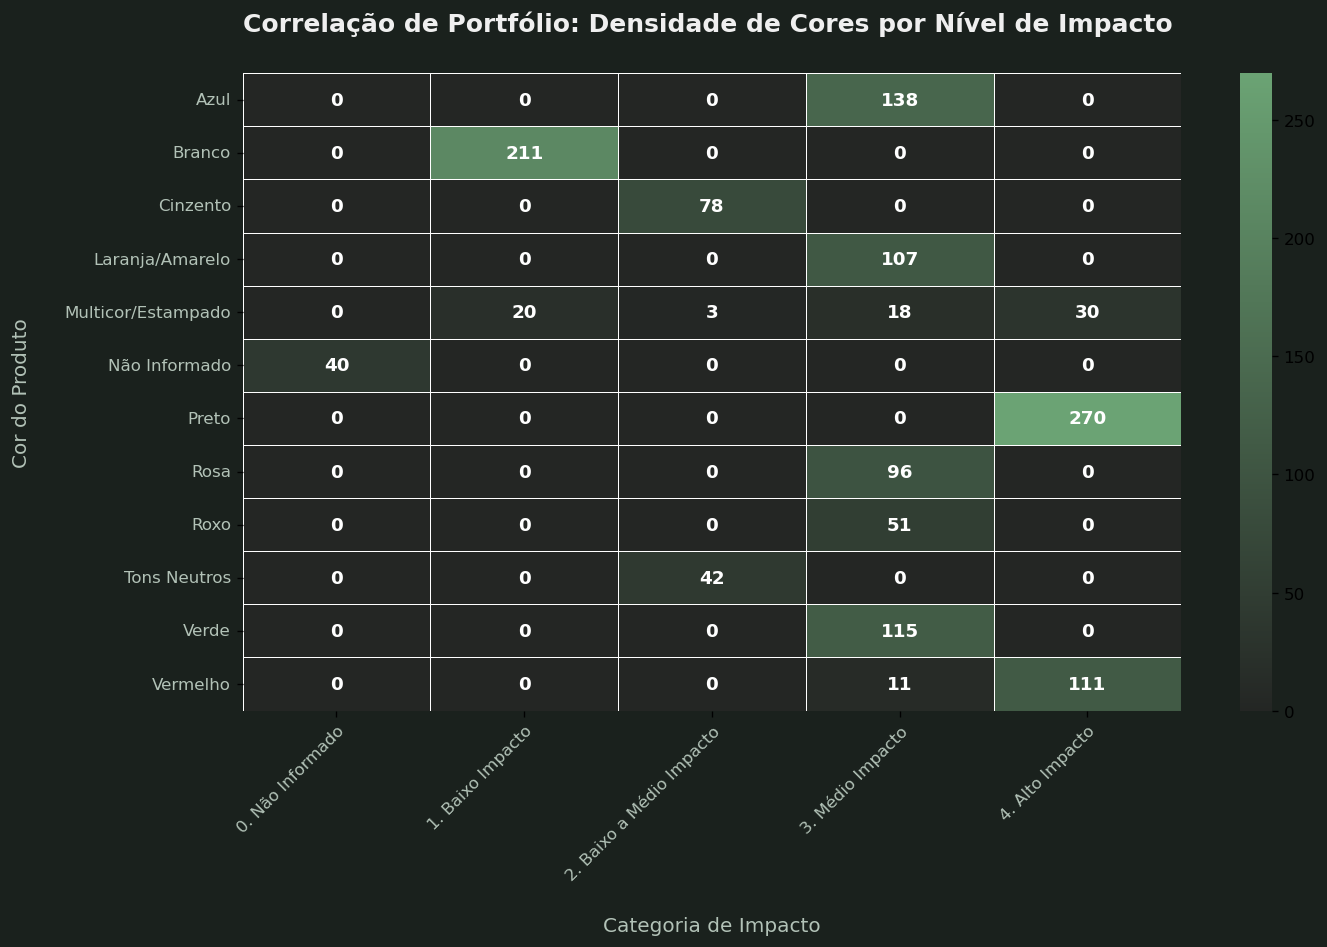

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga e Limpeza de Nulos
df = pd.read_csv('../../../Datasets/limpos_final_csv.csv')
df_filtrado = df[df['product_color_GroupedColourFix'].notna() & df['product_color_GroupedByImpactFix'].notna()].copy()

# Tabela de contingência estrutural
tabela_cruzada = pd.crosstab(df_filtrado['product_color_GroupedColourFix'], df_filtrado['product_color_GroupedByImpactFix']).sort_index()

# 2. Plotagem e Configuração Visual
fig, ax = plt.subplots(figsize=(12, 8), dpi=120, facecolor='#1A211D')
ax.set_facecolor('#1A211D')

sns.heatmap(
    tabela_cruzada, annot=True, fmt='d', 
    cmap=sns.dark_palette("#6BA374", as_cmap=True), 
    linewidths=.5, ax=ax, annot_kws={"size": 11, "weight": "bold"}
)

# 3. Ajustes de Espaçamento Críticos (Solução do Inchaço de Labels)
ax.set_title('Correlação de Portfólio: Densidade de Cores por Nível de Impacto', color='#EFEFEF', fontsize=15, pad=25, weight='bold', loc='left')
ax.set_xlabel('Categoria de Impacto', color='#B2C2B7', fontsize=12, labelpad=20)
ax.set_ylabel('Cor do Produto', color='#B2C2B7', fontsize=12, labelpad=20)

# Rotacionar eixo X em 45° e alinhar à direita para evitar colisões textuais
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', color='#B2C2B7', fontsize=10)
plt.setp(ax.get_yticklabels(), color='#B2C2B7', fontsize=10)

plt.tight_layout()
plt.savefig('correlacao_cores_ajustado.png', facecolor='#1A211D')
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=acb13dac-3e3d-49c3-81b9-b25c403473b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

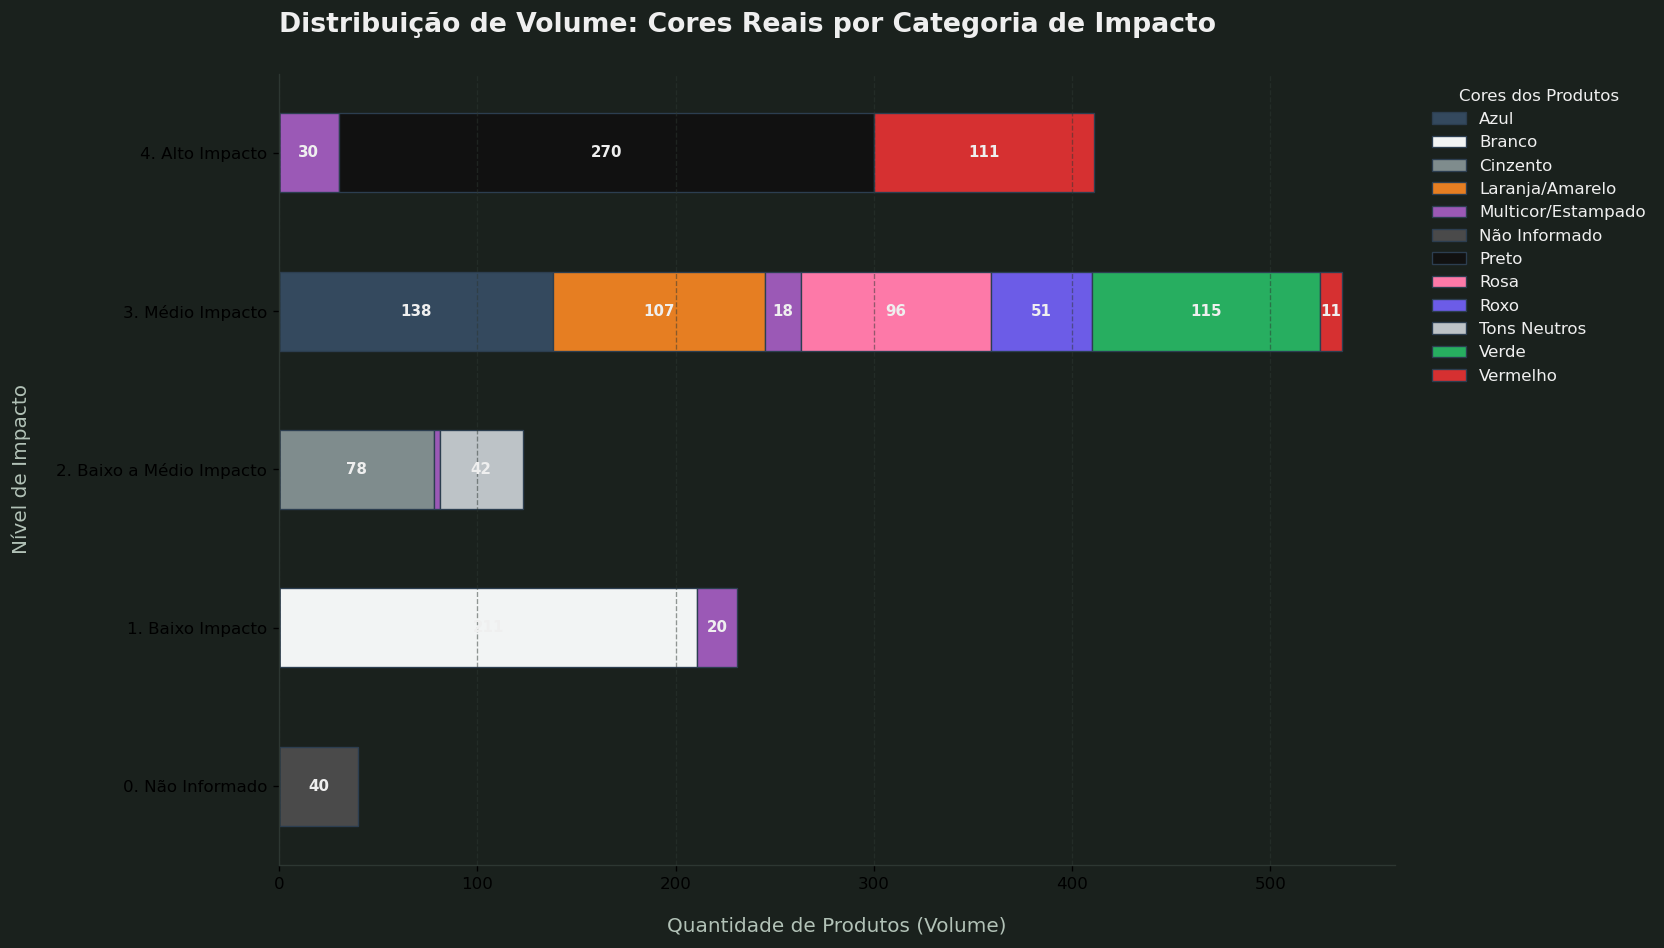

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparação dos dados
df = pd.read_csv('../../../Datasets/limpos_final_csv.csv')
col_cor = 'product_color_GroupedColourFix'
col_impacto = 'product_color_GroupedByImpactFix'

# Filtrar nulos e criar a tabela cruzada (Impacto na linha, Cor na coluna)
df_filtrado = df[df[col_cor].notna() & df[col_impacto].notna()].copy()
tabela_cruzada = pd.crosstab(df_filtrado[col_impacto], df_filtrado[col_cor])

# 2. Definição do mapeamento de cores reais para o gráfico
# Associamos cada nome de categoria à sua respectiva cor visual, usando tons elegantes
mapeamento_cores = {
    'Azul': '#34495E',
    'Branco': '#F2F4F4',
    'Cinzento': '#7F8C8D',
    'Laranja/Amarelo': '#E67E22',
    'Multicor/Estampado': '#9B59B6',
    'Não Informado': '#4A4A4A',
    'Preto': '#111111',
    'Rosa': '#FD79A8',
    'Roxo': '#6C5CE7',
    'Tons Neutros': '#BDC3C7',
    'Verde': '#27AE60',
    'Vermelho': '#D63031'
}

# Garantir que a ordem das cores no gráfico siga a nossa paleta customizada
cores_paleta = [mapeamento_cores[col] for col in tabela_cruzada.columns]

# 3. Configuração do Gráfico (Design Executivo Dark)
cor_fundo = '#1A211D'
plt.rcParams['figure.facecolor'] = cor_fundo
plt.rcParams['axes.facecolor'] = cor_fundo
plt.rcParams['text.color'] = '#EFEFEF'

fig, ax = plt.subplots(figsize=(14, 8), dpi=120)

# Criar o gráfico de barras empilhadas horizontais
tabela_cruzada.plot(
    kind='barh', 
    stacked=True, 
    color=cores_paleta, 
    edgecolor='#2C3E50', 
    linewidth=0.8,
    ax=ax
)

# Adicionar os números/rótulos dentro ou sobre as barras para facilitar a leitura rápida
for container in ax.containers:
    # Mostra o rótulo apenas se o valor for maior que 10 (evita poluição visual com zeros)
    labels = [f'{int(v):d}' if v > 10 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', color='#EFEFEF', fontsize=9, weight='bold')

# Títulos e formatação dos eixos
ax.set_title('Distribuição de Volume: Cores Reais por Categoria de Impacto', color='#EFEFEF', fontsize=16, pad=25, weight='bold', loc='left')
ax.set_xlabel('Quantidade de Produtos (Volume)', color='#B2C2B7', fontsize=12, labelpad=15)
ax.set_ylabel('Nível de Impacto', color='#B2C2B7', fontsize=12, labelpad=15)

# Ajuste das linhas de grade e bordas
ax.grid(axis='x', color='#2D3732', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#2D3732')
ax.spines['bottom'].set_color('#2D3732')

# Posicionar a legenda de forma limpa fora do gráfico
plt.legend(title='Cores dos Produtos', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('impacto_cores_barras.png', facecolor=cor_fundo)
plt.show()

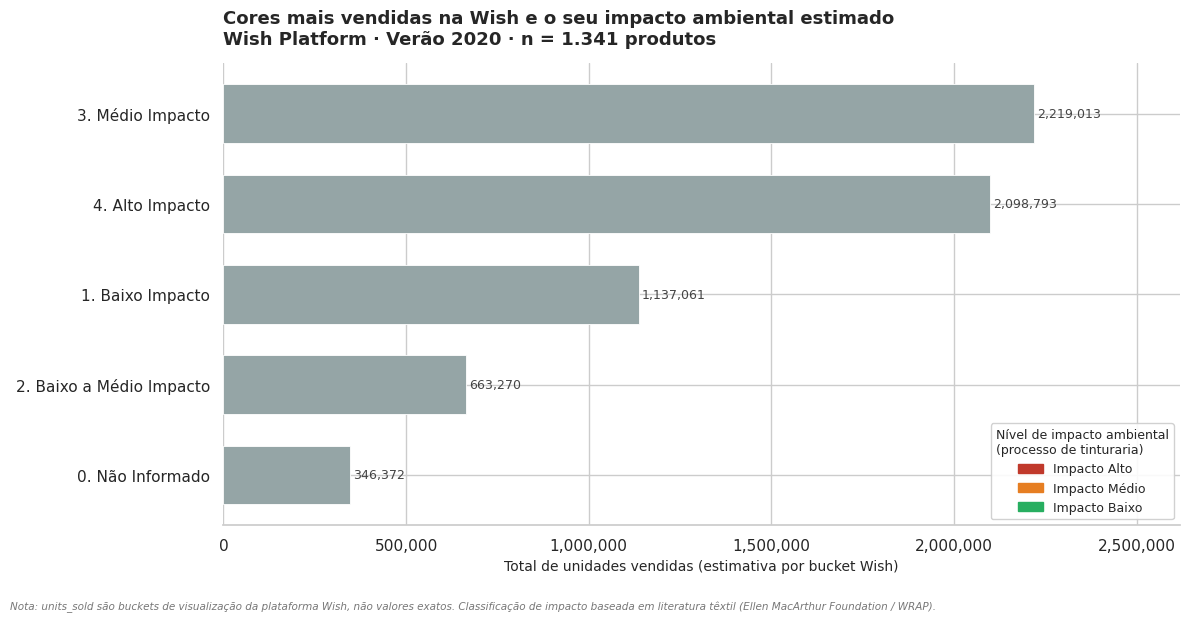

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── 1. CARREGAR DADOS ──────────────────────────────────────────────────────────
df = pd.read_csv("../../../Datasets/limpos_final_csv.csv")

# ── 2. MAPEAMENTO DE IMPACTO AMBIENTAL POR GRUPO DE COR ───────────────────────
# Cores escuras e estampadas exigem mais corantes, processos e água na tinturaria.
# Fonte: literatura têxtil (Ellen MacArthur Foundation / WRAP reports)
impacto_map = {
    "Preto":              "Alto",   # requer múltiplas camadas de corante
    "Multicor/Estampado": "Alto",   # processos complexos de impressão
    "Roxo":               "Alto",   # corantes sintéticos intensivos
    "Vermelho":           "Alto",   # corantes azo — alta toxicidade
    "Azul":               "Médio",  # inclui denim (índigo) — intensivo mas natural
    "Verde":              "Médio",
    "Rosa":               "Médio",
    "Laranja/Amarelo":    "Médio",
    "Cinzento":           "Baixo",
    "Tons Neutros":       "Baixo",  # beige, khaki — menos corante
    "Branco":             "Baixo",  # branqueamento, mas sem corante
    "Não Informado":      "Desconhecido",
}

paleta_impacto = {
    "Alto":         "#C0392B",  # vermelho
    "Médio":        "#E67E22",  # laranja
    "Baixo":        "#27AE60",  # verde
    "Desconhecido": "#95A5A6",  # cinzento
}

# ── 3. AGREGAR VENDAS POR COR ──────────────────────────────────────────────────
df_agg = (
    df.groupby("product_color_GroupedByImpactFix", as_index=False)["units_sold"]
    .sum()
    .rename(columns={
        "product_color_GroupedByImpactFix": "cor_grupo",
        "units_sold": "total_vendido"
    })
)

# Adicionar nível de impacto e cor visual
df_agg["impacto"]   = df_agg["cor_grupo"].map(impacto_map).fillna("Desconhecido")
df_agg["cor_barra"] = df_agg["impacto"].map(paleta_impacto)

# Ordenar do mais vendido para o menos
df_agg = df_agg.sort_values("total_vendido", ascending=False)

# Excluir "Não Informado" da visualização principal (opcional — remover linha abaixo para incluir)
df_agg = df_agg[df_agg["cor_grupo"] != "Não Informado"]

# ── 4. FIGURA ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font="DejaVu Sans")

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    df_agg["cor_grupo"],
    df_agg["total_vendido"],
    color=df_agg["cor_barra"],
    edgecolor="white",
    linewidth=0.6,
    height=0.65,
)

# Inverter eixo y para mostrar o mais vendido no topo
ax.invert_yaxis()

# Valores no fim de cada barra
for bar, val in zip(bars, df_agg["total_vendido"]):
    ax.text(
        bar.get_width() + 8000,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}",
        va="center", ha="left",
        fontsize=9, color="#444"
    )

# ── 5. LEGENDAS E TÍTULOS ──────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=paleta_impacto[lvl], label=f"Impacto {lvl}")
    for lvl in ["Alto", "Médio", "Baixo"]
]
ax.legend(
    handles=legend_patches,
    title="Nível de impacto ambiental\n(processo de tinturaria)",
    loc="lower right",
    framealpha=0.9,
    fontsize=9,
    title_fontsize=9,
)

ax.set_title(
    "Cores mais vendidas na Wish e o seu impacto ambiental estimado\n"
    "Wish Platform · Verão 2020 · n = 1.341 produtos",
    fontsize=13, fontweight="bold", pad=14, loc="left"
)
ax.set_xlabel("Total de unidades vendidas (estimativa por bucket Wish)", fontsize=10)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, df_agg["total_vendido"].max() * 1.18)

# Nota metodológica discreta
fig.text(
    0.01, -0.03,
    "Nota: units_sold são buckets de visualização da plataforma Wish, não valores exatos. "
    "Classificação de impacto baseada em literatura têxtil (Ellen MacArthur Foundation / WRAP).",
    fontsize=7.5, color="#777", style="italic"
)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.savefig("cores_impacto_ambiental.png", dpi=150, bbox_inches="tight")
plt.show()